In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



### Get TIMIT pandas for metadata

In [2]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now

In [3]:
df_paths

[PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_00.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_01.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_02.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_03.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_04.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_05.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_06.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_07.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_dataset_08.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/attn_task_

In [4]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

In [5]:
# pd.concat(meta_df, axis=0)

In [6]:
meta_df.head()

,_original_timit_index,word,source,speaker,sr,signal_length,speaker_sex,sentence_type,sentence_id,dialect_region,...,mixture_signal,distractor_signal,_original_distractor_timit_indices,distractor_words,distractor_speakers,distractor_conditions,distractor_sex,snrs,cue_snr,stim_subset
0,7513,production,test-dr1-faks0-si943,faks0,20000,40000,f,si,si943,dr1,...,"[0.03280280653886981, 0.045145319604222425, 0....","[0.044842268343169164, 0.06321240552500913, 0....","[7462, 9941, 9016, 3631]","[release, country, world, contains]","[mrlk0, mers0, mpwm0, mjac0]",4,mmmm,0,0.0,0
1,3134,majority,train-dr4-falr0-si1325,falr0,20000,40000,f,si,si1325,dr4,...,"[0.059812799799893554, 0.05950236718134872, -0...","[0.033321616417676246, 0.03372167482692411, -0...",ssn,ssn,ssn,ssn,ssn,-6,-6.0,0
2,9119,claimed,test-dr5-fawf0-si1000,fawf0,20000,40000,f,si,si1000,dr5,...,"[0.2377219686295869, 0.18225687370718036, 0.11...","[0.24622171606927987, 0.15934913622359043, 0.0...","[181, 514, 337, 545]","[means, while, effort, young]","[ftbr0, mrws0, mkls0, mtpf0]",4,mmmf,0,0.0,0
3,9125,lower,test-dr5-fawf0-sx10,fawf0,20000,40000,f,sx,sx10,dr5,...,"[-0.538045132526894, -0.5314192488255117, -0.3...","[-0.6896055871440385, -0.683185273069746, -0.5...","[194, 3587]","[students, either]","[ftbr0, mgrp0]",2,mf,0,0.0,0
4,3156,equipment,train-dr4-fbas0-sx37,fbas0,20000,40000,f,sx,sx37,dr4,...,"[-0.0056461801191768435, 0.0050251671625243105...","[-0.007809814846080094, 0.007536774659544499, ...","[209, 3359]","[terms, going]","[fvmh0, fssb0]",2,ff,0,0.0,0


### Get experimental results csv

In [65]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [66]:
results_files


[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv')]

In [67]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)

# set_ix, word, snr, cond, speaker_sex, orig_df_ix = file_name_to_labels(file_name)
# print(file_name)
# print(f"{word} at {snr} dB snr with {cond} target sex ({speaker_sex}), ds = {set_ix} original ix = {orig_df_ix}")




In [68]:
dfs = []
for file in results_files:
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(5460, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [70]:
len(results.participant.unique()

19

In [71]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [72]:
results.head()

,index,participant,guessed_word,stim_path,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy
0,trial 0,p0,working,https://mcdermottlab.mit.edu/mturk_stimuli/img...,24,working,0,ssn,ssn,79,ssn,ssn,1
1,trial 1,p0,cover,https://mcdermottlab.mit.edu/mturk_stimuli/img...,24,while,3,2,f,27,"[appointed, nothing]",mf,0
2,trial 10,p0,subject,https://mcdermottlab.mit.edu/mturk_stimuli/img...,24,followed,0,4,m,156,"[appointed, lower, appointed, lower]",ffff,0
3,trial 100,p0,during,https://mcdermottlab.mit.edu/mturk_stimuli/img...,24,asked,0,4,m,149,"[number, senior, title, system]",mmmm,0
4,trial 101,p0,safety,https://mcdermottlab.mit.edu/mturk_stimuli/img...,24,structure,-9,1,f,54,[status],f,0


In [73]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [74]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [75]:
len(catch_trial_particiapnt_performance)

19

0.5833333333333334

In [76]:
catch_trial_particiapnt_performance

participant
p0     0.500000
p1     0.291667
p12    1.000000
p14    0.666667
p15    0.416667
p16    0.583333
p17    0.166667
p18    0.875000
p19    0.500000
p20    0.916667
p21    0.708333
p22    0.833333
p3     0.833333
p4     0.833333
p5     0.895833
p6     0.555556
p7     0.541667
p8     0.458333
p9     0.833333
Name: accuracy, dtype: float64

In [104]:
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [105]:
good_participants

Index(['p12', 'p18', 'p20', 'p22', 'p3', 'p4', 'p5', 'p9'], dtype='object', name='participant')

In [81]:
good_participants

Index(['p12', 'p18', 'p20', 'p22', 'p3', 'p4', 'p5', 'p9'], dtype='object', name='participant')

In [82]:
good_results = results[results.participant.isin(good_participants)]

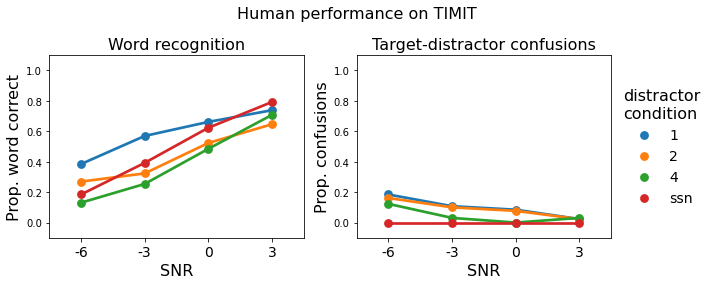

In [94]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=good_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=good_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Human performance on TIMIT', size=fontsize)
plt.tight_layout()


## Get model results all subsets

In [22]:
parent_path = Path('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/')
timit_results = list(parent_path.rglob("*.csv"))

In [23]:
timit_results

[PosixPath('/om2/user/imgriff/projects/End-to-end-ASR-Pytorch/attn_cue_models/attn_timit_task/TIMIT_attn_task_all_targets_MultiDistractorAttnCNN/version_0/metrics.csv')]

In [24]:
model_results = pd.read_csv(timit_results[0])

In [25]:
model_results.shape

(41492, 3)

In [26]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,step
0,1.0,552.0,0
1,0.0,392.0,1
2,0.0,689.0,2
3,1.0,659.0,3
4,0.0,90.0,4


In [27]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [28]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [29]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [30]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [31]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

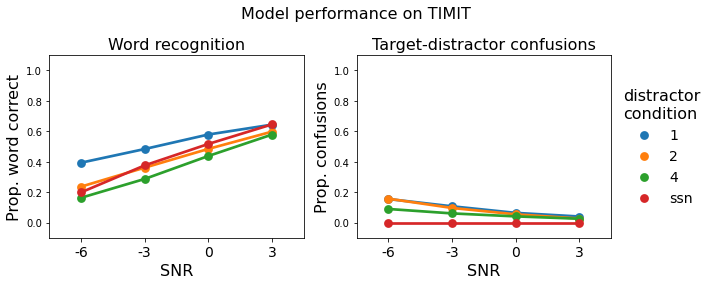

In [32]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=model_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=model_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()


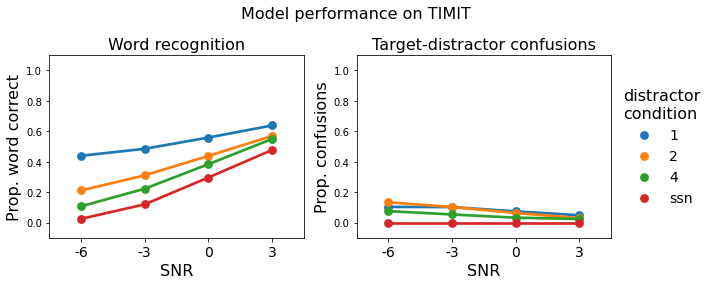

In [44]:
snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs = axs.ravel()

g = sns.pointplot( data=model_results, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[0])

g1 = sns.pointplot( data=model_results, x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_condition',  hue_order = hue_order, ci=None, height=4,
            ax=axs[1])

axs[0].set_title("Word recognition", fontsize=fontsize)
axs[1].set_title("Target-distractor confusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)



axs[0].set_ylim((-0.1,1.1))
axs[1].set_ylim((-0.1,1.1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize-2)
fig.subplots_adjust(top=0.9) # make room for title 
fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()


## Put on same plots 

First look at N talkers by SNR for model and human (separate pannels for model and humans)

Then look at single talker accuracy and sinlge talker confusions ( lines for model and human ) 

In [95]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_40201/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [97]:
all_results = pd.concat([good_results, model_results])

### Error by N Talker 

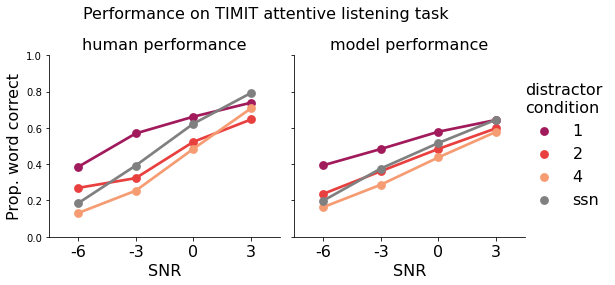

In [98]:
fontsize = 16

snr_order = ['-6', '-3', '0', '3' ]
hue_order = ['1', '2', '4', 'ssn']

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'


g = sns.catplot(kind='point',
    data=all_results,
    x='snr', y='accuracy',
    order = snr_order,
    hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
    col='subject',
    ci=None, seed=1, height=4, aspect=0.75
)

 
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
g.fig.tight_layout()
# g.fig.savefig('../demo_plots/timit_human_v_model.png')

In [99]:

turk_summary_df = (good_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (good_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




In [100]:
turk_summary_df.head()

,snr,participant,distractor_condition,mean
0,-3,p12,1,0.80
1,-3,p12,2,0.30
2,-3,p12,4,0.30
3,-3,p12,ssn,0.40
4,-3,p18,1,0.35


In [101]:
distractor_palette

{'1': (0.63139686, 0.10067417, 0.35664819),
 '2': (0.90848638, 0.24568473, 0.24598324),
 '4': (0.96298491, 0.6126247, 0.45145074),
 'ssn': 'grey'}

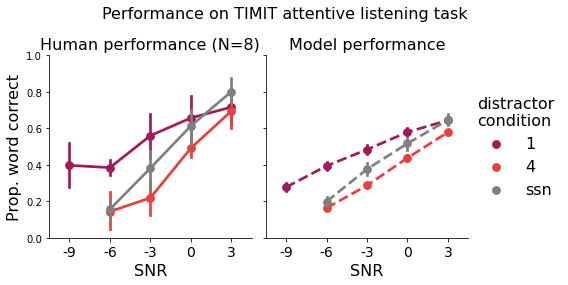

In [102]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'

n_participants = len(turk_summary_df.participant.unique())


fig, axs = plt.subplots(1,2, figsize=(8,4), sharey=True)
axs = axs.ravel()


g = sns.pointplot( data=turk_summary_df, x = 'snr', y = 'mean', order=snr_order,
            hue ='distractor_condition', height=4, error='sem',
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[0])

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', height=4, linestyles='--',
            hue_order=hue_order, palette=distractor_palette,
            ax=axs[1])


axs[0].set_title(f"Human performance (N={n_participants})",
                 fontsize=fontsize)

axs[1].set_title("Model performance", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


# axs[0].set_ylim((-0.02,1))
# axs[1].set_ylim((-0.02,1))


axs[0].get_legend().remove()

sns.move_legend(g1, title='distractor\ncondition', 
                loc="center right", bbox_to_anchor=(1.5, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
plt.ylim(0,1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
fig.suptitle('Performance on TIMIT attentive listening task', size=fontsize)
plt.tight_layout()
# plt.savefig('../demo_plots/timit_human_v_model.svg')

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.63139686, 0.10067417, 0.35664819)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,


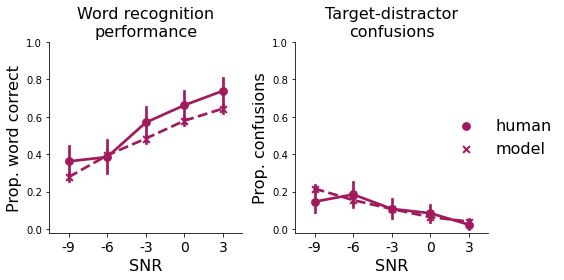

In [103]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1', '4', 'ssn']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['ssn'] = 'grey'

fig, axs = plt.subplots(1,2, figsize=(8,4))
axs = axs.ravel()

n_participants = len(turk_summary_df.participant.unique())
to_plot = all_results[all_results.distractor_condition == '1']

g = sns.pointplot( data=to_plot, x = 'snr', y = 'accuracy', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[0])

g1 = sns.pointplot( data=to_plot, x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['o','x'],
            palette=[distractor_palette['1']] * 2,
            ax=axs[1])

axs[0].set_title(f"Word recognition\nperformance", fontsize=fontsize)
axs[1].set_title("Target-distractor\nconfusions", fontsize=fontsize)


axs[0].set_ylabel("Prop. word correct", fontsize=fontsize)
axs[1].set_ylabel("Prop. confusions", fontsize=fontsize)

axs[0].set_xlabel("SNR", fontsize=fontsize)
axs[1].set_xlabel("SNR", fontsize=fontsize)


g.set_xticklabels(snr_order, size=14)
g1.set_xticklabels(snr_order, size=14)

sns.despine()


axs[0].set_ylim((-0.02,1))
axs[1].set_ylim((-0.02,1))

axs[0].get_legend().remove()
sns.move_legend(g1, title='', # labels=[f"human (N={n_participants})", "model"],
                loc="center right", bbox_to_anchor=(1.4, .5),
                frameon=False, fontsize=fontsize)
# fig.subplots_adjust(top=0.9) # make room for title 
# fig.suptitle('Model performance on TIMIT', size=fontsize)
plt.tight_layout()
# plt.savefig('../demo_plots/timit_single_word_rec_v_confusions.svg')

### Scratch code for looking at talker sex similarity 

In [54]:
x=10

In [55]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['f', 'm', 'ff', 'mf', 'mm', 'ffff', 'mfff', 'mmff', 'mmmf', 'mmmm']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['mmff'] = distractor_palette['mf']

[['f', 'm'], ['ff', 'mf', 'mm'], ['ffff', 'mfff', 'mmff', 'mmmf', 'mmmm']]


In [56]:
good_results.head()

,index,participant,guessed_word,stim_path,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy,confusions,subject
364,trial 0,p3,longer,https://mcdermottlab.mit.edu/mturk_stimuli/img...,19,longer,3,4,f,48,"[great, through, himself, appear]",mmff,1,0,human
365,trial 1,p3,points,https://mcdermottlab.mit.edu/mturk_stimuli/img...,19,points,3,2,m,101,"[think, inside]",mf,1,0,human
366,trial 10,p3,appointed,https://mcdermottlab.mit.edu/mturk_stimuli/img...,19,appointed,3,ssn,ssn,47,ssn,ssn,1,0,human
367,trial 100,p3,years,https://mcdermottlab.mit.edu/mturk_stimuli/img...,19,students,-6,1,f,21,[still],f,0,0,human
368,trial 101,p3,behind,https://mcdermottlab.mit.edu/mturk_stimuli/img...,19,behind,3,1,m,114,[through],f,1,0,human


In [57]:
## Get stats for sex similarity plots:


turk_summary_df = (good_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_sex", 'target_sex'])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_summary_df.head()

,snr,participant,distractor_condition,distractor_sex,target_sex,mean
0,-3,p12,1,f,f,0.500000
1,-3,p12,1,f,m,1.000000
2,-3,p12,1,m,m,0.666667
3,-3,p12,2,ff,f,0.500000
4,-3,p12,2,ff,m,0.000000


In [58]:
turk_summary_df.participant.unique()

array(['p12', 'p18', 'p20', 'p22', 'p3', 'p4', 'p5', 'p9'], dtype=object)

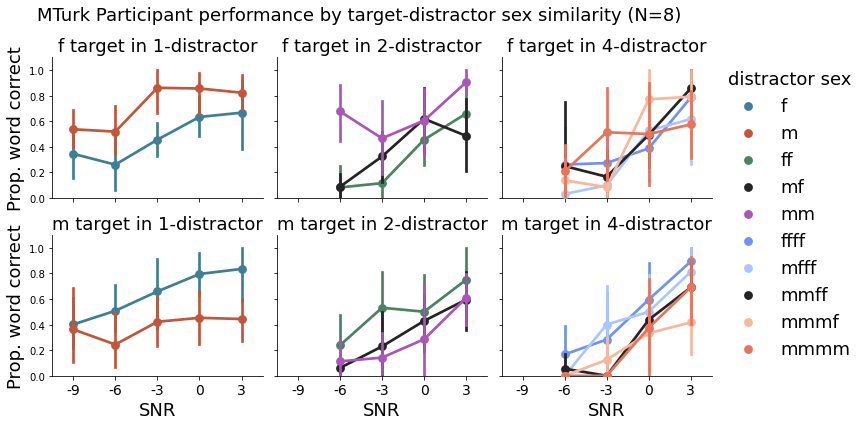

In [59]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-9', '-6', '-3', '0', '3' ]

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18

n_part = len(turk_summary_df.participant.unique())

g = sns.catplot( kind='point',
    data=turk_summary_df[turk_summary_df['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='mean',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
     seed=1,
     height=3,
    palette=distractor_palette,
    order=snr_order,
    error='sem'
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle(f'MTurk Participant performance by target-distractor sex similarity (N={n_part})', size=fontsize)
plt.tight_layout()


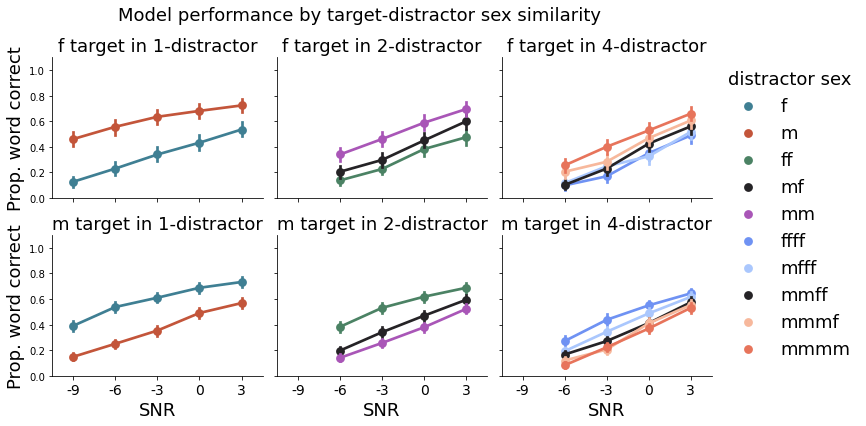

In [60]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-9', '-6', '-3', '0', '3' ]

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18

to_plot = all_results[all_results.subject=='model']

g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='accuracy',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1,
    height=3,
    palette=distractor_palette,
   order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. word correct", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance by target-distractor sex similarity', size=fontsize)
plt.tight_layout()


### Plot Human confusions by target-distractor sex

In [61]:
## Get stats for sex similarity plots:


turk_summary_df = (good_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_sex", 'target_sex'])
                     .confusions
                     .agg(["mean"])
                     .reset_index())

turk_summary_df.head()

,snr,participant,distractor_condition,distractor_sex,target_sex,mean
0,-3,p12,1,f,f,0.000000
1,-3,p12,1,f,m,0.000000
2,-3,p12,1,m,m,0.333333
3,-3,p12,2,ff,f,0.000000
4,-3,p12,2,ff,m,0.000000


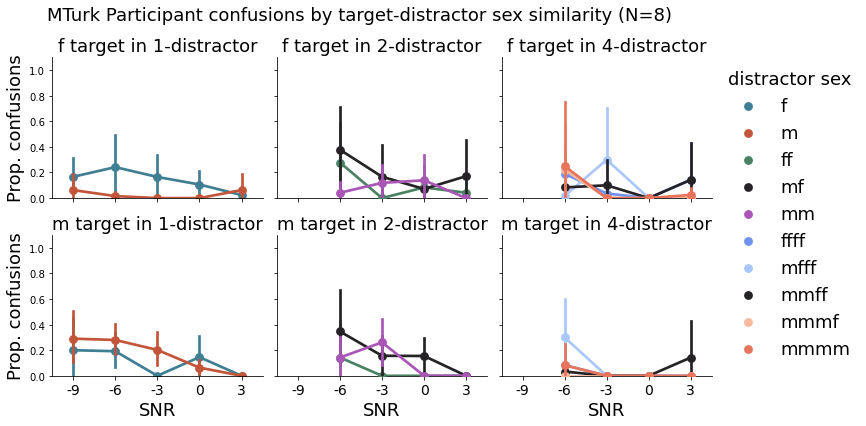

In [62]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-9', '-6', '-3', '0', '3' ]

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18

n_part = len(turk_summary_df.participant.unique())

g = sns.catplot( kind='point',
    data=turk_summary_df[turk_summary_df['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='mean',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1, error='sem',
     height=3,
    palette=distractor_palette,
    order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. confusions", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(-0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle(f'MTurk Participant confusions by target-distractor sex similarity (N={n_part})', size=fontsize)
plt.tight_layout()


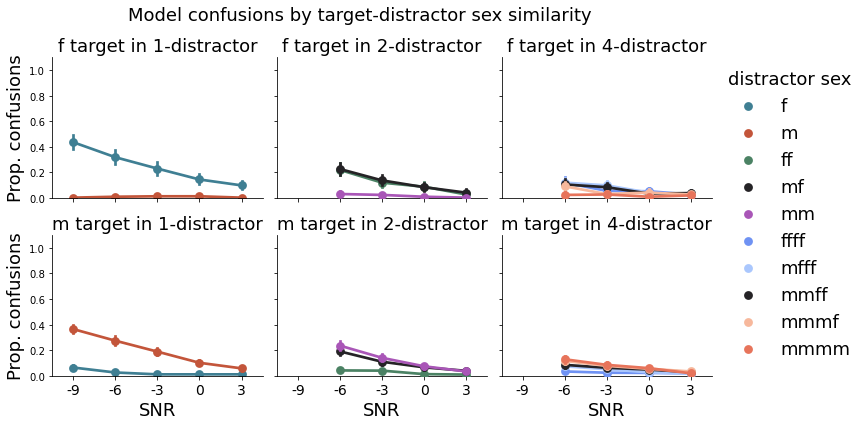

In [63]:
distractor_cond_order = ['1','2', '4']
snr_order = ['-9', '-6', '-3', '0', '3' ]

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

fontsize = 18


to_plot = all_results[all_results.subject=='model']


g = sns.catplot( kind='point',
    data=to_plot[to_plot['distractor_condition'].isin(distractor_cond_order)], 
    x='snr', y='confusions',
    row='target_sex', 
    col='distractor_condition', col_order = distractor_cond_order,
    hue='distractor_sex',
    hue_order=distractor_hue_order,
    seed=1,
    height=3,
    palette=distractor_palette,
    order=snr_order,
)


g.set_xticklabels(fontsize=14)
g.set_axis_labels("SNR", "Prop. confusions", size=fontsize)
g.set_titles("{row_name} target in {col_name}-distractor", size=fontsize)
sns.move_legend(g, title='distractor sex',
                loc="center right", bbox_to_anchor=(1.2, .5),
                frameon=False, fontsize=fontsize, title_fontsize=fontsize)
plt.ylim(0, 1.1)
fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model confusions by target-distractor sex similarity', size=fontsize)
plt.tight_layout()
